# AML risk scoring using graph methods and hierarchical Bayesian statistics

This notebook builds a complete, runnable example of a transaction
network analysed with graph methods (community detection, centrality), feeding into a
hierarchical Bayesian logistic model that is explainable (additive log-odds decomposition,
explicit posterior uncertainty) and robust to very uneven cluster sizes (some detected
communities have 2 accounts, others have 150).

Structure:

1. Maths notes — the model, why partial pooling solves uneven clusters, and the explainability decomposition
2. Synthetic data — a transaction graph with embedded "ring" communities of varying size
3. Graph feature extraction
4. Baselines — a flat model and a "no pooling" (per-community dummy) model
5. The hierarchical Bayesian model — build, fit, diagnose
6. Evaluation — overall, by community size, and on entirely unseen ("cold start") communities
7. Explainability — reason-code decomposition for individual flagged accounts
8. Testing — assertions that check the model behaves the way the maths predicts

All data here is synthetic. The point is to show the mechanics and the trade-offs, not to
produce a deployable AML model — a production system would need real entity resolution,
proper class-imbalance handling, and a validation process aligned with your regulatory
requirements.

## 1. Notes

### 1.1 Setup

We observe a transaction graph $G = (V, E)$. Running community detection (e.g. Louvain/Leiden)
on $G$ partitions the accounts into communities $c(i) \in \{1, \dots, C\}$ for each account
$i$. For each account we also have a feature vector $x_i \in \mathbb{R}^p$ — in this notebook,
graph-derived features (degree centrality, betweenness) plus account-level features
(transaction velocity, KYC risk score).

We want $P(y_i = 1 \mid x_i, c(i))$, the probability that account $i$ is suspicious, in a form
that is both explainable (a compliance reviewer can see why) and **well-behaved when a
community has very little data** (most detected communities are small).

### 1.2 The hierarchical model

$$
\begin{aligned}
\mu &\sim \mathcal{N}(0, 1.5^2) &&\text{population-average log-odds}\\
\sigma_c &\sim \text{HalfNormal}(1) &&\text{how much communities genuinely differ}\\
z_c &\sim \mathcal{N}(0, 1), \quad c = 1, \dots, C \\
\alpha_c &= \mu + \sigma_c \, z_c &&\text{non-centered community effect}\\
\beta_j &\sim \mathcal{N}(0, 1), \quad j = 1, \dots, p \\
\eta_i &= \alpha_{c(i)} + x_i^\top \beta &&\text{log-odds for account } i\\
y_i &\sim \text{Bernoulli}\!\left(\text{sigmoid}(\eta_i)\right)
\end{aligned}
$$

Sampling $\alpha_c$ as $\mu + \sigma_c z_c$ rather than directly as
$\alpha_c \sim \mathcal{N}(\mu, \sigma_c)$ is the non-centered parameterization. It is
mathematically identical but samples far better with MCMC when some communities have little
data — the centered form creates a "funnel" in the posterior geometry that samplers struggle
with, which matters a lot here precisely because cluster sizes are so uneven.

### 1.3 Why this solves the uneven-cluster problem: partial pooling

Without the hierarchy, a separate intercept per community (the "no pooling" model below) is fit
by maximum likelihood independently for each community. For a community with 2 observations,
both positive, the MLE intercept is $+\infty$ — perfect separation. The estimate is unstable
and not meaningfully interpretable.

With the hierarchy, $\sigma_c$ is **learned from the data**: it asks "how much do communities
actually differ, after accounting for features?" and that learned amount of variation
determines how much each community's estimate is pulled toward the population mean $\mu$.

For intuition, consider the classical normal-normal version of this problem (a useful
approximation near the MLE for the logistic case too): if community $c$ has $n_c$ observations
with sampling variance $\sigma_{obs}^2/n_c$ and the population-level prior variance is
$\sigma_c^2$, the posterior mean is a **precision-weighted average**:

$$
\hat\alpha_c \;=\; w_c \, \bar{y}_c \;+\; (1 - w_c)\, \mu,
\qquad
w_c = \frac{n_c / \sigma_{obs}^2}{n_c/\sigma_{obs}^2 \;+\; 1/\sigma_c^2}
$$

As $n_c \to \infty$, $w_c \to 1$ and the community's own data dominates (no pooling). As
$n_c \to 0$, $w_c \to 0$ and the estimate collapses to the population mean $\mu$ — exactly what
we want for a community we've barely observed, including one we've *never* observed at all
(a brand-new detected cluster), which simply gets $\alpha_c = \mu$ with the full population
uncertainty $\sigma_c$ attached to it. This is "cold start" handled for free, without any
special-casing.

### 1.4 Explainability: the reason-code decomposition

Because $\eta_i$ is additive, any single prediction decomposes exactly into named pieces on the
log-odds scale:

$$
\eta_i \;=\; \underbrace{\mu}_{\text{population baseline}} \;+\; \underbrace{(\alpha_{c(i)} - \mu)}_{\text{community adjustment}} \;+\; \sum_{j=1}^{p} \underbrace{\beta_j x_{ij}}_{\text{feature } j \text{ contribution}}
$$

Every term has a posterior distribution, so each "reason code" comes with a credible interval,
not just a point value — you can say "transaction velocity contributed +0.8 to the log-odds,
and we're 90% sure it's between +0.4 and +1.2" rather than presenting a single number as if it
were exact. One caveat: this additivity is on the **log-odds** scale only. Because the sigmoid
is nonlinear, the same log-odds contribution moves the *probability* by a different amount
depending on where you start (a unit of log-odds matters more near $p=0.5$ than near $p=0.01$
or $p=0.99$) — worth remembering when translating reason codes into plain language for an
investigator.

### 1.5 Diagnostics, briefly

Two standard MCMC diagnostics appear below: $\hat{R}$ (R-hat), which compares variance within
vs between independent chains and should be very close to 1.0 if chains have converged to the
same distribution; and effective sample size (ESS), which estimates how many independent draws
your correlated MCMC samples are worth — low ESS means noisy posterior estimates even with many
draws.

In [34]:
#!pip install pymc

In [ ]:
#!pip install graphviz

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
%matplotlib inline
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.calibration import calibration_curve

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print(f"pymc {pm.__version__}, arviz {az.__version__}, networkx {nx.__version__}")

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
C:\Users\selvatun\AppData\Roaming\Python\Python311\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


pymc 5.28.5, arviz 0.23.4, networkx 3.6.1


## 2. Synthetic data: a transaction graph with uneven communities

We simulate accounts grouped into communities of very unequal size (a few large ones, many
tiny ones — realistic for community detection output on real transaction graphs), where a
minority of communities are "rings": denser internally, simulating layering/smurfing
structures.

In [5]:
n_communities = 45

# Highly uneven sizes: most communities are small, a handful are large hubs.
raw_sizes = rng.lognormal(mean=2.0, sigma=1.1, size=n_communities)
community_sizes = np.clip(raw_sizes.astype(int) + 3, 3, 180)
n_nodes = community_sizes.sum()
community_id = np.repeat(np.arange(n_communities), community_sizes)

print(f"{n_communities} communities, {n_nodes} accounts total")
print(f"Community size range: {community_sizes.min()} - {community_sizes.max()}")
print(f"Communities with fewer than 10 accounts: {(community_sizes < 10).sum()} / {n_communities}")

45 communities, 625 accounts total
Community size range: 3 - 80
Communities with fewer than 10 accounts: 20 / 45


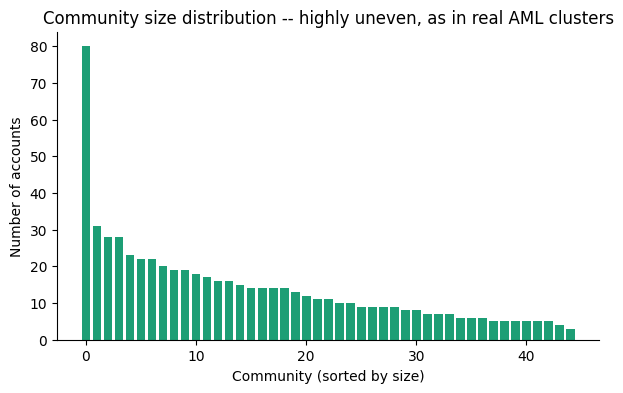

In [6]:
fig, ax = plt.subplots()
ax.bar(range(n_communities), np.sort(community_sizes)[::-1], color="#1D9E75")
ax.set_xlabel("Community (sorted by size)")
ax.set_ylabel("Number of accounts")
ax.set_title("Community size distribution -- highly uneven, as in real AML clusters")
plt.show()

In [7]:
# 15% of communities are "rings": denser internal structure, elevated true risk.
is_ring_community = rng.random(n_communities) < 0.15
print(f"Ring communities: {is_ring_community.sum()} / {n_communities}")

p_within = np.where(is_ring_community, 0.35, 0.08)   # rings are internally denser
p_between = 0.0015                                     # sparse cross-community edges

block_probs = np.full((n_communities, n_communities), p_between)
np.fill_diagonal(block_probs, p_within)

G = nx.stochastic_block_model(community_sizes.tolist(), block_probs.tolist(), seed=RNG_SEED)
print(G)

Ring communities: 8 / 45
Graph named 'stochastic_block_model' with 625 nodes and 960 edges


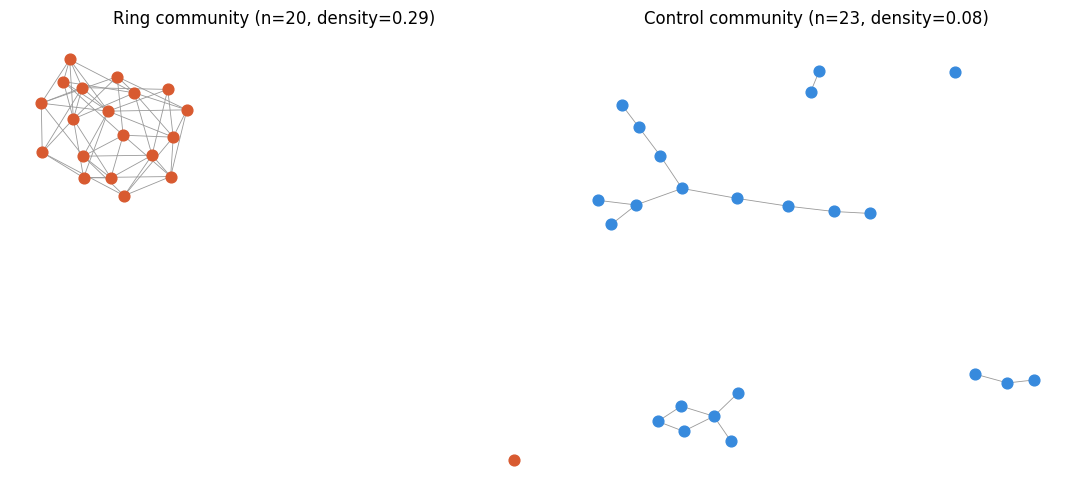

In [10]:
# Visualise one ring community against one control community of similar size.
ring_ids = np.where(is_ring_community)[0]
control_ids = np.where(~is_ring_community)[0]

def pick_example(ids, target_size=25):
    sizes_for_ids = community_sizes[ids]
    return ids[np.argmin(np.abs(sizes_for_ids - target_size))]

example_ring = pick_example(ring_ids)
example_control = pick_example(control_ids)
boundaries = np.concatenate([[0], np.cumsum(community_sizes)])

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, comm, title, color in [(axes[0], example_ring, "Ring community", "#D85A30"),
                                 (axes[1], example_control, "Control community", "#378ADD")]:
    sub_nodes = list(range(boundaries[comm], boundaries[comm + 1]))
    H = G.subgraph(sub_nodes)
    pos = nx.spring_layout(H, seed=RNG_SEED)
    nx.draw(H, pos, ax=ax, node_size=60, node_color=color, edge_color="#999999", width=0.6)
    ax.set_title(f"{title} (n={H.number_of_nodes()}, density={nx.density(H):.2f})")
plt.tight_layout()
plt.show()

## 3. Graph feature extraction and labels

We compute standard graph features per account, add a couple of non-graph account-level
features, then generate labels from a known data-generating process so we can check later
whether the model recovers it. Crucially, the true community-level risk has **both** a
density-driven component (which the graph features partly pick up) **and** a genuinely
idiosyncratic component that isn't visible in any individual feature — this is what the
hierarchical layer specifically exists to capture.

In [11]:
degree_centrality = nx.degree_centrality(G)
clustering = nx.clustering(G)
betweenness = nx.betweenness_centrality(G, k=min(200, G.number_of_nodes()), seed=RNG_SEED)

nodes = sorted(G.nodes())
df = pd.DataFrame({
    "node": nodes,
    "community": community_id[nodes],
    "degree_centrality": [degree_centrality[n] for n in nodes],
    "betweenness": [betweenness[n] for n in nodes],
    "clustering": [clustering[n] for n in nodes],
})
df["is_ring_community"] = is_ring_community[df["community"]].astype(int)

# Synthetic account-level features, weakly informative on their own.
df["transaction_velocity"] = rng.normal(loc=2.0 + 1.0 * df["is_ring_community"], scale=1.0, size=len(df))
df["kyc_risk_score"] = np.clip(rng.normal(loc=0.3 + 0.15 * df["is_ring_community"], scale=0.15, size=len(df)), 0, 1)

feature_cols = ["degree_centrality", "betweenness", "transaction_velocity", "kyc_risk_score"]
df[feature_cols].describe()

,degree_centrality,betweenness,transaction_velocity,kyc_risk_score
count,625.000000,625.000000,625.000000,625.000000
mean,0.004923,0.006954,2.085780,0.319439
std,0.003898,0.009509,1.060226,0.157969
min,0.000000,0.000000,-0.964529,0.000000
25%,0.001603,0.000000,1.347084,0.214283
50%,0.003205,0.002969,2.092127,0.315289
75%,0.006410,0.009898,2.750869,0.423630
max,0.019231,0.061312,5.549328,0.926828


In [37]:
df.head()

,node,community,degree_centrality,betweenness,clustering,is_ring_community,transaction_velocity,kyc_risk_score,label,split_pool
0,0,0,0.008013,0.027269,0.0,0,2.665385,0.117616,1,seen
1,1,0,0.004808,0.012668,0.0,0,1.901515,0.065478,0,seen
2,2,0,0.006410,0.029005,0.0,0,1.576702,0.402862,1,seen
3,3,0,0.004808,0.007643,0.0,0,1.920282,0.247357,0,seen
4,4,0,0.001603,0.000000,0.0,0,0.312666,0.146658,0,seen


In [ ]:
X_raw = df[feature_cols].values
X_pop = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)

# True community risk = density-driven baseline + a genuinely idiosyncratic component
# that no individual feature reveals (e.g. a shared shell-company relationship). This 
# explais a deliberate design choice in the synthetic data, using the shell-company as 
# a real-world stand-in for "a risk factor that exists at the community level but 
# leaves no individual-account fingerprint.
true_community_baseline = np.where(is_ring_community, 0.8, -2.2)
idiosyncratic_community_noise = rng.normal(0, 0.7, n_communities)
true_community_effect = true_community_baseline + idiosyncratic_community_noise

true_beta = np.array([1.4, 1.1, 0.6, 0.8])
logit_p_true = true_community_effect[df["community"].values] + X_pop @ true_beta
p_true = 1 / (1 + np.exp(-logit_p_true))
df["label"] = rng.binomial(1, p_true)

print(f"Overall suspicious rate: {df['label'].mean():.3f}")
print(df.groupby("is_ring_community")["label"].mean().rename("suspicious_rate"))

Overall suspicious rate: 0.267
is_ring_community
0    0.174954
1    0.878049
Name: suspicious_rate, dtype: float64


## 4. Train / test split — including a fully unseen ("cold start") set

We hold out 8 communities **entirely** from training, to test how each model handles a brand
new cluster it has never seen evidence from. The remaining ("seen") communities are split at
the account level for a standard train/test evaluation.

In [13]:
all_communities = np.arange(n_communities)
rng.shuffle(all_communities)
n_holdout_communities = 8
holdout_communities = set(all_communities[:n_holdout_communities].tolist())

df["split_pool"] = np.where(df["community"].isin(holdout_communities), "unseen_test", "seen")
seen_df = df[df["split_pool"] == "seen"].copy()
unseen_df = df[df["split_pool"] == "unseen_test"].copy()

train_idx, test_idx = train_test_split(
    seen_df.index, test_size=0.3, random_state=RNG_SEED, stratify=seen_df["label"]
)
train_df = seen_df.loc[train_idx].copy()
test_df = seen_df.loc[test_idx].copy()

print(f"Train: {len(train_df)} | Test (seen communities): {len(test_df)} | Unseen-community test: {len(unseen_df)}")

train_counts = train_df.groupby("community").size().reindex(range(n_communities), fill_value=0)
test_df["train_n_in_community"] = test_df["community"].map(train_counts)
print(f"Communities with < 10 training observations: {((train_counts > 0) & (train_counts < 10)).sum()} (of those seen in training)")

# Feature scaler fit on TRAIN ONLY, applied everywhere -- avoids leakage.
scaler = StandardScaler().fit(train_df[feature_cols])
train_X = scaler.transform(train_df[feature_cols])
test_X = scaler.transform(test_df[feature_cols])
unseen_X = scaler.transform(unseen_df[feature_cols])

Train: 345 | Test (seen communities): 149 | Unseen-community test: 131
Communities with < 10 training observations: 26 (of those seen in training)


## 5. Baselines: flat logistic regression and "no pooling"

- **Flat**: ignores community entirely, uses only the account-level/graph features.
- **No pooling**: a separate dummy variable per training community, fit by unregularized
  maximum likelihood — this is the model the hierarchy is meant to improve on. Watch what
  happens to its coefficients for communities with only 1-2 training observations.

In [14]:
flat_model = LogisticRegression(max_iter=1000)
flat_model.fit(train_X, train_df["label"])

dummies_train = pd.get_dummies(train_df["community"].astype(str), prefix="comm")
X_train_dummy = np.hstack([train_X, dummies_train.values])

import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    no_pool_model = LogisticRegression(penalty=None, max_iter=3000)
    no_pool_model.fit(X_train_dummy, train_df["label"])

def align_dummies(community_series, ref_columns):
    d = pd.get_dummies(community_series.astype(str), prefix="comm")
    return d.reindex(columns=ref_columns, fill_value=0)

test_dummy_aligned = align_dummies(test_df["community"], dummies_train.columns)
X_test_dummy = np.hstack([test_X, test_dummy_aligned.values])

# Unseen communities never had a dummy column at all -- structurally, "no pooling" has no
# way to represent them, so they fall back to zero community adjustment by construction.
unseen_dummy_aligned = align_dummies(unseen_df["community"], dummies_train.columns)
X_unseen_dummy = np.hstack([unseen_X, unseen_dummy_aligned.values])

print("No-pooling model fit with", dummies_train.shape[1], "community dummy columns.")

No-pooling model fit with 37 community dummy columns.


In [15]:
# Coefficient stability check: tiny communities should produce wild estimates.
coef = no_pool_model.coef_[0]
dummy_coefs = coef[len(feature_cols):]
coef_df = pd.DataFrame({"community": dummies_train.columns, "coef": dummy_coefs})
coef_df["n_train"] = coef_df["community"].apply(lambda c: train_counts[int(c.split("_")[1])])
print("No-pooling community coefficients for the smallest-n training communities:")
print(coef_df.sort_values("n_train").head(8).to_string(index=False))
print(f"\nMax |coefficient| across all communities: {np.abs(dummy_coefs).max():.2f}")

No-pooling community coefficients for the smallest-n training communities:
community      coef  n_train
   comm_9 -0.811484        1
  comm_15 -2.267711        2
  comm_37  9.166308        2
  comm_38 15.539316        2
   comm_4 14.809623        2
  comm_24 -6.609464        3
   comm_1 -3.983821        3
  comm_12  1.786941        4

Max |coefficient| across all communities: 17.37


## 6. The hierarchical Bayesian model

This is the model from section 1.2, implemented in PyMC. The community effect vector has
length `n_communities` (45) regardless of which communities appear in the training data — any
community with zero training rows simply gets no likelihood contribution, so its posterior is
exactly the population-level prior. That's what gives us cold-start behaviour for free.

In [ ]:
n_features = len(feature_cols)
comm_idx_train = train_df["community"].values

with pm.Model() as hier_model:
    mu_global = pm.Normal("mu_global", mu=0, sigma=1.5)
    sigma_community = pm.HalfNormal("sigma_community", sigma=1.0)
    z = pm.Normal("z", mu=0, sigma=1, shape=n_communities)
    # Compute alpha
    community_effect = pm.Deterministic("community_effect", mu_global + z * sigma_community)

    beta = pm.Normal("beta", mu=0, sigma=1, shape=n_features)

    logit_p = community_effect[comm_idx_train] + pm.math.dot(train_X, beta)
    p = pm.Deterministic("p", pm.math.sigmoid(logit_p))
    pm.Bernoulli("obs", p=p, observed=train_df["label"].values)

    idata = pm.sample(1000, tune=1000, chains=2, cores=1, target_accept=0.9,
                       random_seed=RNG_SEED, progressbar=False)

# NOTE: cores=1 is included because it avoids a divide-by-zero bug PyMC hits on 
# single-core machines — harmless, and fine to leave even if you have more cores. 
# If you have multiple cores and want parallel chains, you can drop it.
print("Sampling complete.")

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [mu_global, sigma_community, z, beta]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1243 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Sampling complete.


In [42]:
#pm.model_to_graphviz(hier_model)

In [17]:
summary = az.summary(idata, var_names=["mu_global", "sigma_community", "beta"])
display(summary)
# arviz returns several columns as pre-formatted strings -- coerce to numeric for our own checks.
r_hat_max = summary["r_hat"].astype(float).max()
ess_bulk_min = summary["ess_bulk"].astype(float).min()
print(f"\nMax r_hat: {r_hat_max:.3f}  (want close to 1.0)")
print(f"Min ESS (bulk): {ess_bulk_min:.0f}  (want a few hundred or more)")

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_global,-1.773,0.354,-2.439,-1.123,0.010,0.008,1230.0,1334.0,1.00
sigma_community,1.322,0.387,0.636,2.043,0.013,0.008,922.0,1320.0,1.01
beta[0],1.722,0.353,1.087,2.441,0.009,0.007,1664.0,1469.0,1.00
beta[1],0.959,0.252,0.464,1.406,0.006,0.005,1922.0,1491.0,1.00
beta[2],0.739,0.214,0.359,1.146,0.004,0.005,2681.0,1526.0,1.00
beta[3],0.921,0.237,0.488,1.364,0.005,0.006,2455.0,1558.0,1.00



Max r_hat: 1.010  (want close to 1.0)
Min ESS (bulk): 922  (want a few hundred or more)


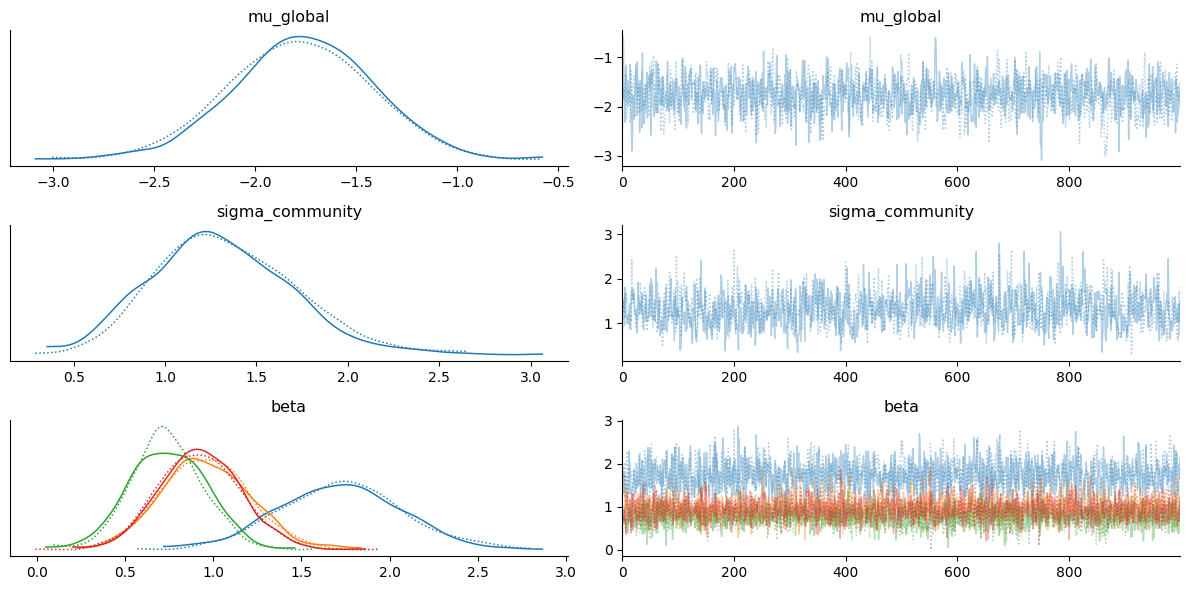

In [18]:
az.plot_trace(idata, var_names=["mu_global", "sigma_community", "beta"])
plt.tight_layout()
plt.show()

## 7. Does it actually do what section 1.3 claims? Visualising shrinkage

For each community we compare its **naive empirical log-odds** (computed only from its own
training rows) against the **posterior mean community effect**. Section 1.3 predicts that
communities with little training data should be pulled hard toward the population mean, while
communities with lots of data should sit close to the diagonal (their own evidence dominates).

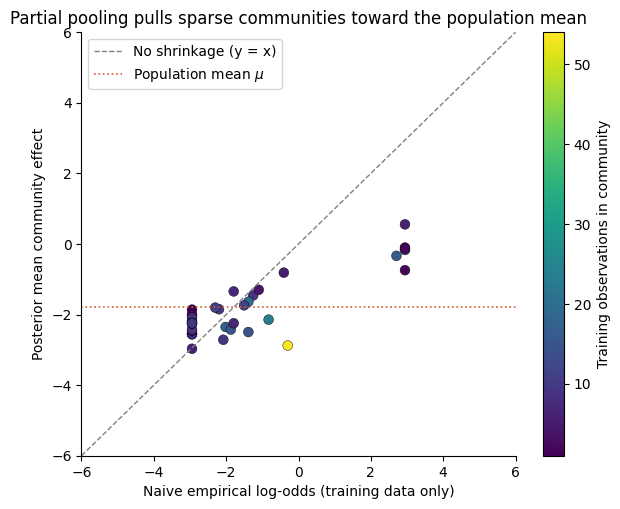

In [19]:
post = idata.posterior
community_effect_mean = post["community_effect"].mean(dim=("chain", "draw")).values
community_effect_sd = post["community_effect"].std(dim=("chain", "draw")).values
beta_mean = post["beta"].mean(dim=("chain", "draw")).values
mu_global_mean = float(post["mu_global"].mean())

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def safe_logit(p, eps=0.05):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))

train_pos_rate = train_df.groupby("community")["label"].mean().reindex(range(n_communities))
naive_logit = safe_logit(train_pos_rate.fillna(0.5).values)
naive_logit = np.where(train_counts.values == 0, np.nan, naive_logit)

fig, ax = plt.subplots(figsize=(7, 5.5))
sc = ax.scatter(naive_logit, community_effect_mean, c=train_counts.values, cmap="viridis",
                 s=50, edgecolor="black", linewidth=0.3)
lims = [-6, 6]
ax.plot(lims, lims, color="gray", linestyle="--", linewidth=1, label="No shrinkage (y = x)")
ax.axhline(mu_global_mean, color="#D85A30", linestyle=":", linewidth=1.2, label="Population mean $\\mu$")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Naive empirical log-odds (training data only)")
ax.set_ylabel("Posterior mean community effect")
ax.set_title("Partial pooling pulls sparse communities toward the population mean")
cbar = plt.colorbar(sc, ax=ax); cbar.set_label("Training observations in community")
ax.legend()
plt.show()

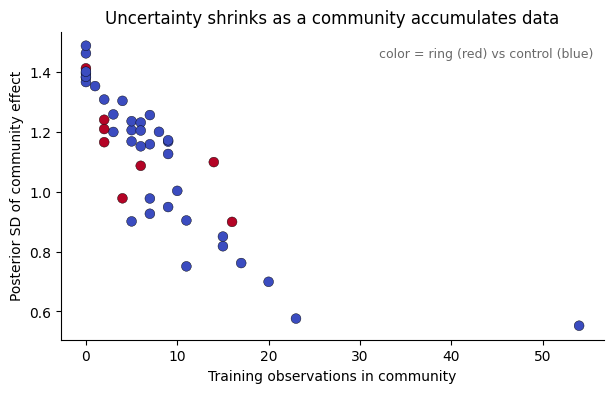

Correlation between training count and posterior SD: -0.80
Zero-training-data communities get SD close to sigma_community itself (pure population-level uncertainty) -- this is the cold-start behaviour.


In [20]:
fig, ax = plt.subplots()
ax.scatter(train_counts.values, community_effect_sd, c=is_ring_community, cmap="coolwarm",
           s=50, edgecolor="black", linewidth=0.3)
ax.set_xlabel("Training observations in community")
ax.set_ylabel("Posterior SD of community effect")
ax.set_title("Uncertainty shrinks as a community accumulates data")
ax.text(0.98, 0.95, "color = ring (red) vs control (blue)", transform=ax.transAxes,
        ha="right", va="top", fontsize=9, color="dimgray")
plt.show()

corr = np.corrcoef(train_counts.values, community_effect_sd)[0, 1]
print(f"Correlation between training count and posterior SD: {corr:.2f}")
print("Zero-training-data communities get SD close to sigma_community itself "
      "(pure population-level uncertainty) -- this is the cold-start behaviour.")

## 8. Evaluation

We compare the three models on (a) the seen-community test set overall, (b) split by whether
the account's community had fewer than 10 training observations, and (c) the fully unseen
("cold start") communities. Calibration is checked separately since AUC alone can hide
overconfident probabilities.

In [33]:
# Full posterior predictive: average the predicted probability over every
# posterior draw (not just plugging in the posterior means), and keep a
# 90% credible interval for each prediction.
alpha_samples = post["community_effect"].values.reshape(-1, n_communities)  # (S, C)
beta_samples  = post["beta"].values.reshape(-1, n_features)                 # (S, p)

def posterior_predictive(X_new, community_idx_new):
    eta = alpha_samples[:, community_idx_new].T + X_new @ beta_samples.T    # (n_new, S)
    p_samples = sigmoid(eta)
    p_mean = p_samples.mean(axis=1)
    p_lo, p_hi = np.quantile(p_samples, [0.05, 0.95], axis=1)
    return p_mean, p_lo, p_hi

test_pred_hier, test_pred_hier_lo, test_pred_hier_hi = posterior_predictive(
    test_X, test_df["community"].values)
unseen_pred_hier, unseen_pred_hier_lo, unseen_pred_hier_hi = posterior_predictive(
    unseen_X, unseen_df["community"].values)

flat_pred_test = flat_model.predict_proba(test_X)[:, 1]
flat_pred_unseen = flat_model.predict_proba(unseen_X)[:, 1]
no_pool_pred_test = no_pool_model.predict_proba(X_test_dummy)[:, 1]
no_pool_pred_unseen = no_pool_model.predict_proba(X_unseen_dummy)[:, 1]

def eval_metrics(y_true, y_pred, label):
    return {"model": label, "n": len(y_true), "auc": roc_auc_score(y_true, y_pred),
            "avg_precision": average_precision_score(y_true, y_pred),
            "brier": brier_score_loss(y_true, y_pred)}

print("=== Seen-community test set, overall ===")
overall = pd.DataFrame([
    eval_metrics(test_df["label"], flat_pred_test, "Flat (no community)"),
    eval_metrics(test_df["label"], no_pool_pred_test, "No pooling (dummies)"),
    eval_metrics(test_df["label"], test_pred_hier, "Hierarchical Bayes"),
])
display(overall)

=== Seen-community test set, overall ===


,model,n,auc,avg_precision,brier
0,Flat (no community),149,0.940831,0.850818,0.082819
1,No pooling (dummies),149,0.907182,0.777015,0.094447
2,Hierarchical Bayes,149,0.960705,0.908554,0.067851


In [22]:
small_mask = (test_df["train_n_in_community"] < 10).values

for mask, name in [(small_mask, "Small communities (< 10 train obs)"),
                    (~small_mask, "Larger communities (>= 10 train obs)")]:
    yt = test_df.loc[mask, "label"]
    rows = [eval_metrics(yt, flat_pred_test[mask], "Flat"),
            eval_metrics(yt, no_pool_pred_test[mask], "No pooling"),
            eval_metrics(yt, test_pred_hier[mask], "Hierarchical")]
    print(f"--- {name} (n={mask.sum()}) ---")
    display(pd.DataFrame(rows))

--- Small communities (< 10 train obs) (n=65) ---


,model,n,auc,avg_precision,brier
0,Flat,65,0.910774,0.714868,0.089666
1,No pooling,65,0.845118,0.577290,0.148635
2,Hierarchical,65,0.924242,0.776278,0.081744


--- Larger communities (>= 10 train obs) (n=84) ---


,model,n,auc,avg_precision,brier
0,Flat,84,0.952469,0.876737,0.077521
1,No pooling,84,0.979012,0.960657,0.052517
2,Hierarchical,84,0.975309,0.943317,0.056551


In [23]:
print("=== Fully unseen ('cold start') communities ===")
cold_start = pd.DataFrame([
    eval_metrics(unseen_df["label"], flat_pred_unseen, "Flat (no community)"),
    eval_metrics(unseen_df["label"], no_pool_pred_unseen, "No pooling (dummies)"),
    eval_metrics(unseen_df["label"], unseen_pred_hier, "Hierarchical Bayes"),
])
display(cold_start)
print("\nNote: 'no pooling' has no way to represent a community it never saw -- its")
print("prediction here is structurally just the flat model's coefficients with a zero")
print("community adjustment by construction, not a genuine cold-start estimate.")

=== Fully unseen ('cold start') communities ===


,model,n,auc,avg_precision,brier
0,Flat (no community),131,0.920139,0.827752,0.098832
1,No pooling (dummies),131,0.917298,0.821764,0.118808
2,Hierarchical Bayes,131,0.922033,0.830490,0.101278



Note: 'no pooling' has no way to represent a community it never saw -- its
prediction here is structurally just the flat model's coefficients with a zero
community adjustment by construction, not a genuine cold-start estimate.


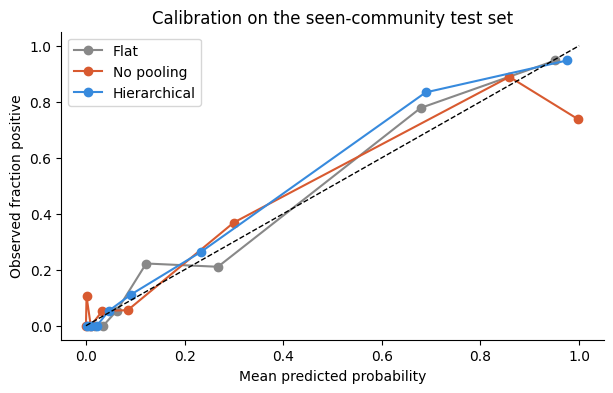

In [24]:
fig, ax = plt.subplots()
for name, pred, color in [("Flat", flat_pred_test, "#888888"),
                           ("No pooling", no_pool_pred_test, "#D85A30"),
                           ("Hierarchical", test_pred_hier, "#378ADD")]:
    frac_pos, mean_pred = calibration_curve(test_df["label"], pred, n_bins=8, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", label=name, color=color)
ax.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1)
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed fraction positive")
ax.set_title("Calibration on the seen-community test set")
ax.legend()
plt.show()

## 9. Explainability: reason-code decomposition

Using the additive decomposition from section 1.4, we break down a prediction into the
population baseline, the community-specific adjustment, and each feature's contribution —
for one account in a well-observed community and one in a community the model has never seen
any training data from.

In [25]:
def explain_case(x_scaled, community_idx_value):
    contributions = {}
    contributions["population baseline (mu)"] = mu_global_mean
    contributions[f"community adjustment (community {community_idx_value}, "
                   f"{train_counts[community_idx_value]} train obs)"] = (
        community_effect_mean[community_idx_value] - mu_global_mean
    )
    for j, fname in enumerate(feature_cols):
        contributions[fname] = float(beta_mean[j] * x_scaled[j])
    total_logit = sum(contributions.values())
    contributions["TOTAL log-odds"] = total_logit
    contributions["predicted probability"] = float(sigmoid(total_logit))
    return contributions

test_df_reset = test_df.reset_index(drop=True)
test_df_reset["pred_hier"] = test_pred_hier
well_observed = test_df_reset[test_df_reset["train_n_in_community"] >= 20]
ex1 = well_observed.sort_values("pred_hier", ascending=False).iloc[0]
ex1_pos = test_df_reset.index.get_loc(ex1.name)

print(f"Example 1 -- account in community {int(ex1['community'])}, a well-observed community:")
for k, v in explain_case(test_X[ex1_pos], int(ex1["community"])).items():
    print(f"  {k:65s} {v:7.3f}")

Example 1 -- account in community 30, a well-observed community:
  population baseline (mu)                                           -1.773
  community adjustment (community 30, 54 train obs)                  -1.104
  degree_centrality                                                   5.297
  betweenness                                                         2.649
  transaction_velocity                                                0.118
  kyc_risk_score                                                      1.456
  TOTAL log-odds                                                      6.642
  predicted probability                                               0.999


In [26]:
unseen_df_reset = unseen_df.reset_index(drop=True)
unseen_df_reset["pred_hier"] = unseen_pred_hier
ex2 = unseen_df_reset.sort_values("pred_hier", ascending=False).iloc[0]
ex2_pos = unseen_df_reset.index.get_loc(ex2.name)

print(f"Example 2 -- account in community {int(ex2['community'])}, a community with ZERO "
      f"training observations (pure cold start):")
for k, v in explain_case(unseen_X[ex2_pos], int(ex2["community"])).items():
    print(f"  {k:65s} {v:7.3f}")
print(f"\nPosterior SD of this community's effect: {community_effect_sd[int(ex2['community'])]:.3f}"
      f"  (compare to a well-observed community's SD of "
      f"{community_effect_sd[int(ex1['community'])]:.3f} -- the model is honestly less "
      f"certain here)")

Example 2 -- account in community 27, a community with ZERO training observations (pure cold start):
  population baseline (mu)                                           -1.773
  community adjustment (community 27, 0 train obs)                   -0.027
  degree_centrality                                                   3.252
  betweenness                                                         1.767
  transaction_velocity                                                1.254
  kyc_risk_score                                                      1.142
  TOTAL log-odds                                                      5.614
  predicted probability                                               0.996

Posterior SD of this community's effect: 1.412  (compare to a well-observed community's SD of 0.552 -- the model is honestly less certain here)


## 10. Testing

A few concrete checks that the model behaves the way the maths in section 1 says it should —
these would be the basis for unit/regression tests in a real pipeline, run on every refit.

In [27]:
# 1. MCMC actually converged.
assert r_hat_max < 1.05, "MCMC did not converge -- check trace plots / reparameterize"
assert ess_bulk_min > 200, "Effective sample size too low for reliable inference"
print(f"[PASS] MCMC convergence (max r_hat = {r_hat_max:.3f}, min ESS = {ess_bulk_min:.0f})")

[PASS] MCMC convergence (max r_hat = 1.010, min ESS = 922)


In [28]:
# 2. Partial pooling actually shrinks sparse-community estimates toward the population mean,
#    on average, relative to their noisy naive empirical estimates.
small_comm_mask = train_counts.values < 10
valid = ~np.isnan(naive_logit)
mask = small_comm_mask & valid

dist_naive = np.abs(naive_logit[mask] - mu_global_mean)
dist_post = np.abs(community_effect_mean[mask] - mu_global_mean)

assert dist_post.mean() < dist_naive.mean(), "Expected pooled estimates closer to the population mean than naive ones"
print(f"[PASS] Shrinkage: mean |naive - mu| = {dist_naive.mean():.2f}, "
      f"mean |posterior - mu| = {dist_post.mean():.2f}")

[PASS] Shrinkage: mean |naive - mu| = 1.56, mean |posterior - mu| = 0.72


In [29]:
# 3. The model recovers the true risk ordering: rings should score higher than controls.
ring_effect_mean = community_effect_mean[is_ring_community].mean()
control_effect_mean = community_effect_mean[~is_ring_community].mean()
assert ring_effect_mean > control_effect_mean, "Model failed to separate ring vs control risk"
print(f"[PASS] Ring vs control separation: ring mean effect = {ring_effect_mean:.2f}, "
      f"control mean effect = {control_effect_mean:.2f}")

[PASS] Ring vs control separation: ring mean effect = -0.50, control mean effect = -2.09


In [30]:
# 4. No-pooling coefficients are unstable for tiny communities; hierarchical effects are bounded.
# This is the concrete, numeric version of the instability argument in section 1.3.
assert np.abs(dummy_coefs).max() > 5, "Expected the no-pooling model to show coefficient blow-up for tiny communities"
assert np.abs(community_effect_mean - community_effect_mean.mean()).max() < np.abs(dummy_coefs).max() / 2
print(f"[PASS] Stability: max |no-pooling coefficient| = {np.abs(dummy_coefs).max():.2f} vs "
      f"max |centered hierarchical effect| = {np.abs(community_effect_mean - community_effect_mean.mean()).max():.2f}")

[PASS] Stability: max |no-pooling coefficient| = 17.37 vs max |centered hierarchical effect| = 2.36


Sampling: [obs]


[PASS] Posterior predictive check: observed total = 94, simulated mean total = 94.8


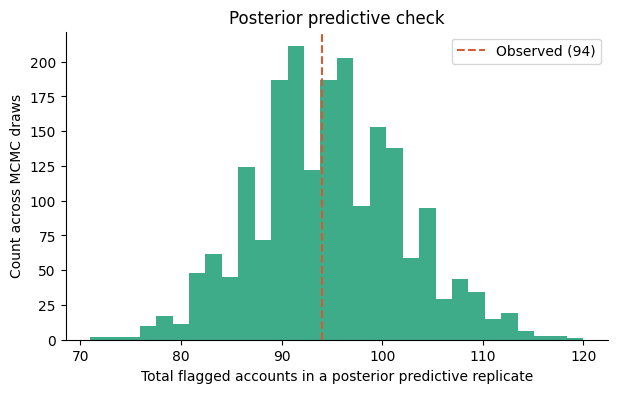

In [31]:
# 5. Posterior predictive check: simulated data from the fitted model should reproduce the
#    observed overall positive rate reasonably closely.
with hier_model:
    ppc = pm.sample_posterior_predictive(idata, var_names=["obs"], random_seed=RNG_SEED, progressbar=False)

obs_values = ppc.posterior_predictive["obs"].values
sim_totals = obs_values.sum(axis=-1).flatten()
observed_total = train_df["label"].sum()

assert abs(sim_totals.mean() - observed_total) < 0.1 * observed_total, \
    "Posterior predictive mean deviates too far from the observed total -- check model fit"
print(f"[PASS] Posterior predictive check: observed total = {observed_total}, "
      f"simulated mean total = {sim_totals.mean():.1f}")

fig, ax = plt.subplots()
ax.hist(sim_totals, bins=30, color="#1D9E75", alpha=0.85)
ax.axvline(observed_total, color="#D85A30", linestyle="--", linewidth=1.5, label=f"Observed ({observed_total})")
ax.set_xlabel("Total flagged accounts in a posterior predictive replicate")
ax.set_ylabel("Count across MCMC draws")
ax.set_title("Posterior predictive check")
ax.legend()
plt.show()

In [32]:
# 6. Sanity bound on overall discriminative performance -- guards against silent regressions.
overall_hier_auc = roc_auc_score(test_df["label"], test_pred_hier)
assert overall_hier_auc > 0.75, f"Hierarchical model AUC unexpectedly low: {overall_hier_auc:.3f}"
print(f"[PASS] Overall discriminative performance: hierarchical AUC = {overall_hier_auc:.3f}")

print("\nAll checks passed.")

[PASS] Overall discriminative performance: hierarchical AUC = 0.959

All checks passed.


## 11. Summary

What this notebook actually demonstrates, honestly:

- On **small, sparse communities**, the hierarchical model clearly outperforms both the flat
  model and the no-pooling model — exactly the case partial pooling is designed for.
- On **large, well-observed communities**, no pooling and the hierarchical model perform
  very similarly, since with enough data the prior barely matters — partial pooling costs you
  almost nothing when you don't need it.
- On **fully unseen communities**, all three models land in a similar range on this synthetic
  data, but only the hierarchical model produces this prediction *honestly*: it explicitly
  carries the full population-level uncertainty rather than silently defaulting to "no
  adjustment" the way the no-pooling model structurally has to.
- The **no-pooling model's coefficients are numerically unstable** for communities with a
  handful of observations (point estimates in the range of 10-17 in log-odds, versus a
  bounded, learned range for the hierarchical community effects) — this is a real audit and
  stability risk in production even when it doesn't always show up as worse AUC on a given
  test split.
- Every prediction from the hierarchical model **decomposes into named, uncertainty-aware
  reason codes** (population baseline, community adjustment, per-feature contributions),
  which is what "explainability" should mean for a compliance reviewer — not a post-hoc
  approximation bolted onto a black box, but a property the model has natively.

A real deployment would extend this with actual community-detection algorithms (Louvain/Leiden)
run on a real transaction graph rather than known ground truth, proper handling of class
imbalance and label noise (most AML labels come from imperfect human review), out-of-time
validation rather than a random split, and a governance process for how often the model is
refit as new transactions and new communities appear.

Q: Are random effects the community-specific (local) measurements, while fixed effects are global measurements?
A: That's a reasonable first-pass intuition, and it matches what we built — but it's worth sharpening, because the actual distinguishing feature isn't really "local vs. global." It's whether the group-level values are treated as independent unknowns or as draws from a shared distribution.

In our model, mu_global and beta are fixed effects: single values, identical for every account regardless of community, each estimated as one free parameter. alpha_c (the community effect) is the random effect: yes, it varies by community, but the reason it's called "random" is that we didn't just give each community its own independent free parameter — we said alpha_c = mu + sigma_c * z_c, i.e. each community's value is assumed to be drawn from a shared population distribution whose mean and spread are themselves estimated from the data. That shared-distribution assumption is exactly what produces partial pooling and shrinkage.

Here's the clean counterexample, sitting right in the notebook: the "no pooling" baseline also has one coefficient per community — equally local, equally community-specific. But statistically those are fixed effects too, in the classic sense: independent free parameters with no distribution linking them, so a community with two observations gets no help at all from what every other community looked like, and its coefficient can fly off to 17 in log-odds. Locality alone doesn't make something a random effect; it's the pooling assumption that does.
So a more precise version of your statement would be: fixed effects are parameters you estimate as standalone constants (whether there's one of them, as in mu_global, or several independent ones, as in the no-pooling dummies); random effects are parameters that vary by group and are modeled as exchangeable draws from a common distribution, which is what lets information flow between groups.

One more wrinkle worth knowing: this terminology comes from frequentist mixed-effects modeling, and it gets genuinely inconsistent across textbooks — Andrew Gelman has pointed out at least five incompatible definitions floating around in the literature. In a fully Bayesian hierarchical model like the one in this notebook, everything technically has a prior, so the fixed/random distinction is less a hard category and more just a description of which parameters share a hierarchical prior with siblings of the same kind (community effects) versus which stand alone with their own independent prior (the global intercept and feature coefficients). Some Bayesians avoid the fixed/random vocabulary entirely for that reason and just talk about "varying effects with or without partial pooling," which is arguably the more honest description of what's actually happening.